In [0]:
# =========================================================
# Análise: Vantagem de jogar como mandante por arena
# Pergunta: Existe vantagem significativa em jogar como mandante?
# Comparação: Mandante vs Visitante por arena
# =========================================================

import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Consulta SQL
# ---------------------------------------------------------
query = """
WITH resultados_por_arena AS (
    SELECT
        arena,
        COUNT(*) AS jogos,
        SUM(CASE WHEN mandante_placar > visitante_placar THEN 1 ELSE 0 END) AS vitorias_mandante,
        SUM(CASE WHEN visitante_placar > mandante_placar THEN 1 ELSE 0 END) AS vitorias_visitante
    FROM fato_partida
    GROUP BY arena
)

SELECT
    arena,
    jogos,
    ROUND(
        CAST(vitorias_mandante AS DOUBLE) / CAST(jogos AS DOUBLE) * 100,
        2
    ) AS taxa_vitoria_mandante_pct,
    ROUND(
        CAST(vitorias_visitante AS DOUBLE) / CAST(jogos AS DOUBLE) * 100,
        2
    ) AS taxa_vitoria_visitante_pct
FROM resultados_por_arena
ORDER BY jogos DESC
"""

# Executa a consulta
df_resultado = spark.sql(query)

# Exibe a tabela (fica salva no .ipynb)
display(df_resultado)

arena,jogos,taxa_vitoria_mandante_pct,taxa_vitoria_visitante_pct
Maracanã,631,51.35,20.92
Mineirão,459,53.59,22.22
Morumbi,413,55.45,16.95
Couto Pereira,295,47.46,28.14
Serra Dourada,235,48.94,25.96
Orlando Scarpelli,219,43.38,24.66
Pacaembu,213,54.46,21.6
Estádio Raimundo Sampaio,201,50.25,29.85
Beira Rio,200,58.5,18.0
Vila Belmiro,192,54.69,17.19


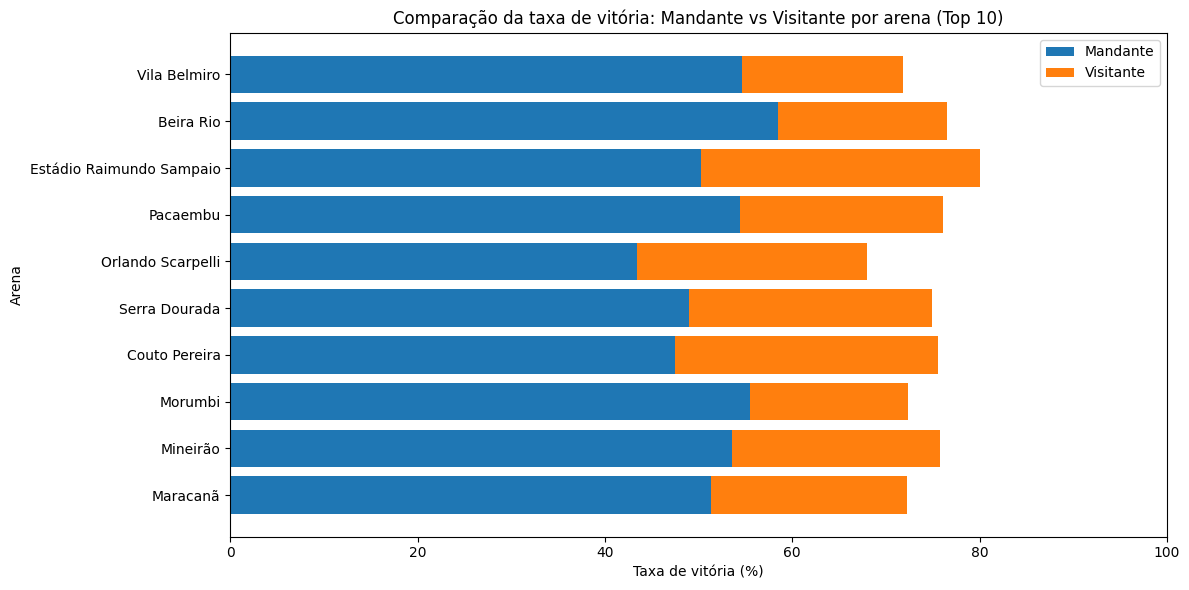

In [0]:
# ---------------------------------------------------------
# Gráfico comparativo
# Mandante vs Visitante por arena
# (Top 10 arenas com mais partidas)
# ---------------------------------------------------------

# Converte para Pandas
pdf = df_resultado.limit(10).toPandas()

plt.figure(figsize=(12, 6))

plt.barh(
    pdf["arena"],
    pdf["taxa_vitoria_mandante_pct"],
    label="Mandante"
)

plt.barh(
    pdf["arena"],
    pdf["taxa_vitoria_visitante_pct"],
    label="Visitante",
    left=pdf["taxa_vitoria_mandante_pct"]
)

plt.xlabel("Taxa de vitória (%)")
plt.ylabel("Arena")
plt.title("Comparação da taxa de vitória: Mandante vs Visitante por arena (Top 10)")
plt.xlim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()
